In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
DATA_DIR = '/kaggle/input/datasets/ahadahmad01/facial-recognition-dataset/archive-3'
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
TEST_DIR = os.path.join(DATA_DIR, 'test')

IMG_SIZE = (48, 48)
BATCH_SIZE = 64

class_names = sorted(os.listdir(TRAIN_DIR))
print("Classes:", class_names)

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [3]:
def count_images(directory):
    counts = {}
    for cls in sorted(os.listdir(directory)):
        cls_path = os.path.join(directory, cls)
        counts[cls] = len(os.listdir(cls_path))
    return counts

train_counts = count_images(TRAIN_DIR)
test_counts = count_images(TEST_DIR)

summary_df = pd.DataFrame({'Train': train_counts, 'Test': test_counts})
summary_df['Total'] = summary_df['Train'] + summary_df['Test']
summary_df

,Train,Test,Total
angry,3995,958,4953
disgust,436,111,547
fear,4097,1024,5121
happy,7215,1774,8989
neutral,4965,1233,6198
sad,4830,1247,6077
surprise,3171,831,4002


In [4]:
print(f"Total training images: {summary_df['Train'].sum()}")
print(f"Total test images: {summary_df['Test'].sum()}")
print(f"Number of classes: {len(class_names)}")
print(f"Image size: {IMG_SIZE}, Mode: Grayscale")

Total training images: 28709
Total test images: 7178
Number of classes: 7
Image size: (48, 48), Mode: Grayscale


In [5]:
from PIL import Image

sample_img_path = os.path.join(TRAIN_DIR, class_names[0], os.listdir(os.path.join(TRAIN_DIR, class_names[0]))[0])
sample_img = Image.open(sample_img_path)
print(f"Sample image size: {sample_img.size}, mode: {sample_img.mode}")

Sample image size: (48, 48), mode: L


In [6]:
import hashlib

def file_hash(path):
    with open(path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

hashes = {}
dup_count = 0
for cls in class_names:
    cls_dir = os.path.join(TRAIN_DIR, cls)
    for fname in os.listdir(cls_dir)[:500]:  # sample check for speed; remove slice for a full scan
        h = file_hash(os.path.join(cls_dir, fname))
        if h in hashes:
            dup_count += 1
        else:
            hashes[h] = fname

print(f"Duplicate images found (sampled check): {dup_count}")

Duplicate images found (sampled check): 80


In [7]:
corrupted = []
for split_dir in [TRAIN_DIR, TEST_DIR]:
    for cls in class_names:
        cls_dir = os.path.join(split_dir, cls)
        for fname in os.listdir(cls_dir):
            try:
                img = Image.open(os.path.join(cls_dir, fname))
                img.verify()
            except Exception:
                corrupted.append(os.path.join(cls_dir, fname))

print(f"Corrupted/unreadable images: {len(corrupted)}")

Corrupted/unreadable images: 0


In [8]:
print("Class names:", class_names)
print("\nTrain distribution:")
print(summary_df['Train'])
print("\nClass imbalance ratio (max/min):", summary_df['Train'].max() / summary_df['Train'].min())

Class names: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Train distribution:
angry       3995
disgust      436
fear        4097
happy       7215
neutral     4965
sad         4830
surprise    3171
Name: Train, dtype: int64

Class imbalance ratio (max/min): 16.548165137614678


In [9]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='categorical',
    class_names=class_names,
    color_mode='grayscale',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42,
    validation_split=0.1,
    subset='training'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='categorical',
    class_names=class_names,
    color_mode='grayscale',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42,
    validation_split=0.1,
    subset='validation'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels='inferred',
    label_mode='categorical',
    class_names=class_names,
    color_mode='grayscale',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Normalize pixel values to [0,1]
normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

# Prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

Found 28709 files belonging to 7 classes.
Using 25839 files for training.


I0000 00:00:1785415060.824325      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 28709 files belonging to 7 classes.
Using 2870 files for validation.
Found 7178 files belonging to 7 classes.


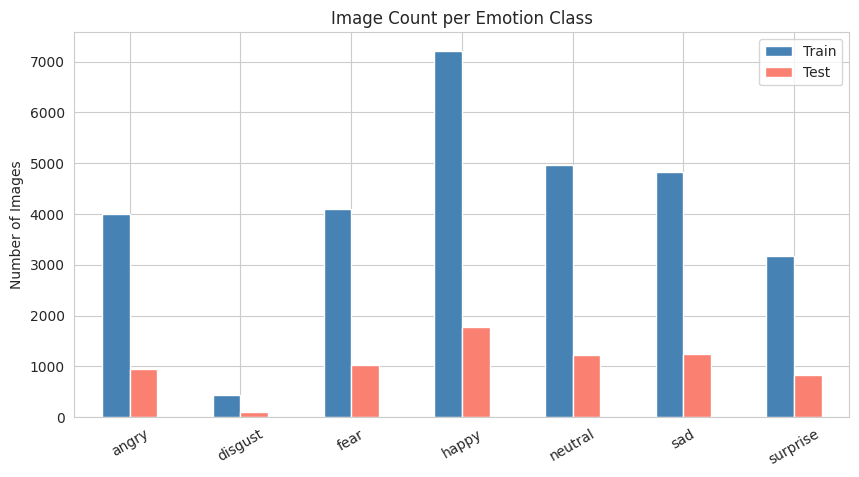

In [10]:
summary_df[['Train','Test']].plot(kind='bar', figsize=(10,5), color=['steelblue','salmon'])
plt.title('Image Count per Emotion Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=30)
plt.show()

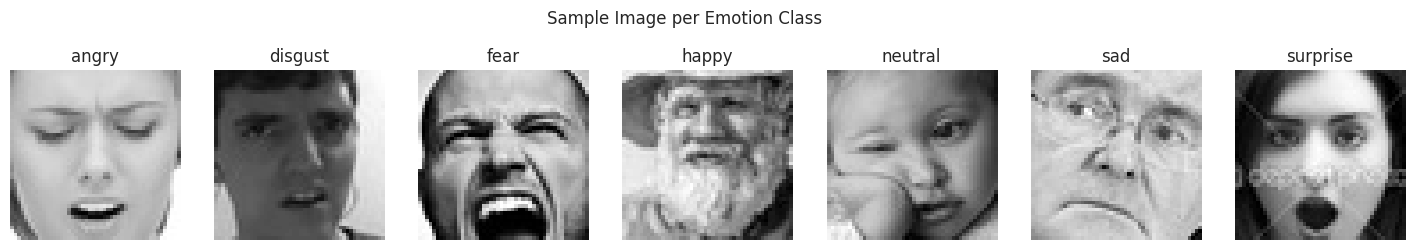

In [11]:
fig, axes = plt.subplots(1, 7, figsize=(18,3))
for i, cls in enumerate(class_names):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    sample_file = os.listdir(cls_dir)[0]
    img = Image.open(os.path.join(cls_dir, sample_file))
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(cls)
    axes[i].axis('off')
plt.suptitle('Sample Image per Emotion Class')
plt.show()

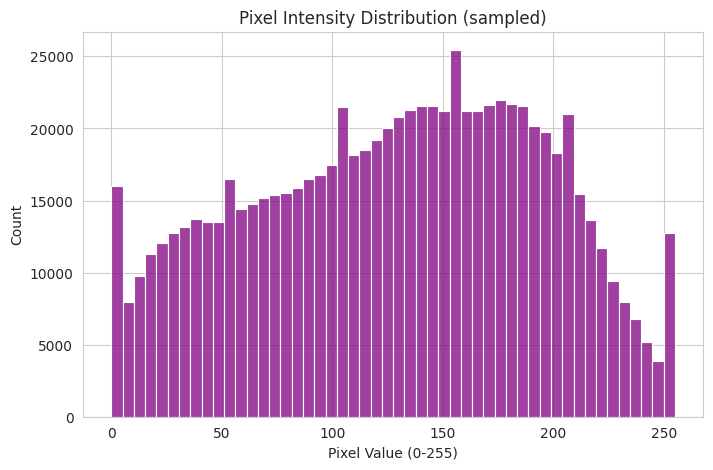

In [12]:
sample_pixels = []
for cls in class_names:
    cls_dir = os.path.join(TRAIN_DIR, cls)
    for fname in os.listdir(cls_dir)[:50]:
        img = np.array(Image.open(os.path.join(cls_dir, fname)))
        sample_pixels.extend(img.flatten())

plt.figure(figsize=(8,5))
sns.histplot(sample_pixels, bins=50, color='purple')
plt.title('Pixel Intensity Distribution (sampled)')
plt.xlabel('Pixel Value (0-255)')
plt.show()

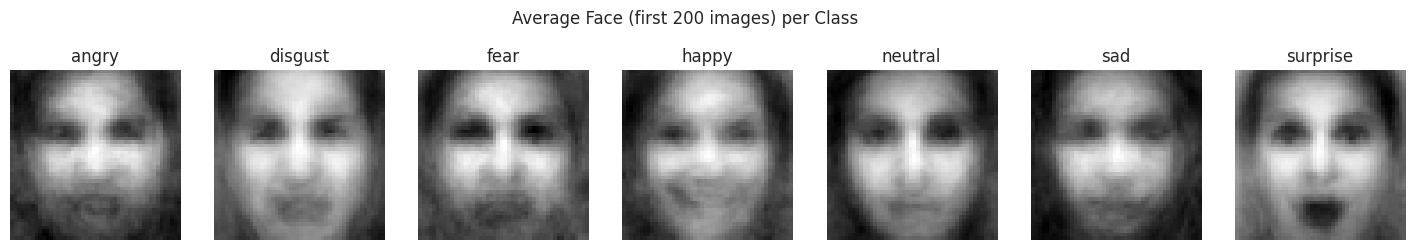

In [13]:
fig, axes = plt.subplots(1, 7, figsize=(18,3))
for i, cls in enumerate(class_names):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    imgs = []
    for fname in os.listdir(cls_dir)[:200]:
        img = np.array(Image.open(os.path.join(cls_dir, fname)).resize(IMG_SIZE))
        imgs.append(img)
    avg_img = np.mean(imgs, axis=0)
    axes[i].imshow(avg_img, cmap='gray')
    axes[i].set_title(cls)
    axes[i].axis('off')
plt.suptitle('Average Face (first 200 images) per Class')
plt.show()

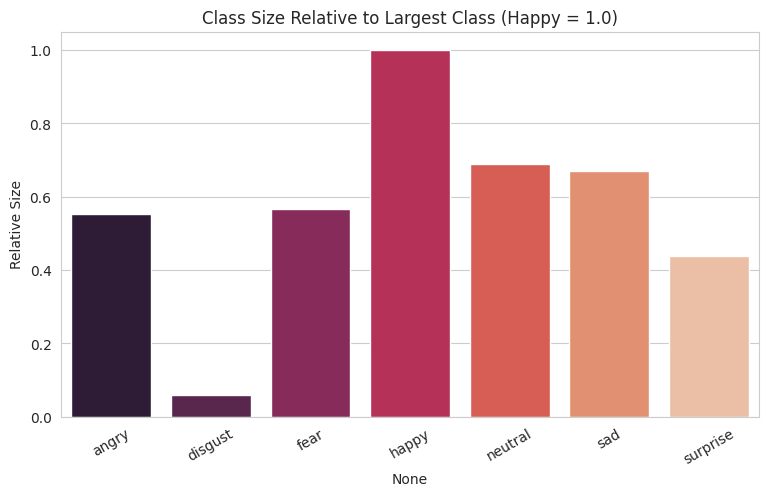

In [14]:
imbalance_ratio = summary_df['Train'] / summary_df['Train'].max()
plt.figure(figsize=(9,5))
sns.barplot(x=imbalance_ratio.index, y=imbalance_ratio.values, palette='rocket')
plt.title('Class Size Relative to Largest Class (Happy = 1.0)')
plt.ylabel('Relative Size')
plt.xticks(rotation=30)
plt.show()

In [15]:
print("Corrupted images found:", len(corrupted))

Corrupted images found: 0


In [16]:
blank_like = 0
for cls in class_names:
    cls_dir = os.path.join(TRAIN_DIR, cls)
    for fname in os.listdir(cls_dir)[:300]:
        img = np.array(Image.open(os.path.join(cls_dir, fname)))
        if img.std() < 10:  # very low variance = likely blank/uniform image
            blank_like += 1

print(f"Near-blank/low-variance images found (sampled check): {blank_like}")

Near-blank/low-variance images found (sampled check): 1


In [17]:
for images, labels in train_ds.take(1):
    print("Label batch shape:", labels.shape)
    print("Example one-hot label:", labels[0].numpy())

Label batch shape: (64, 7)
Example one-hot label: [0. 0. 0. 0. 0. 1. 0.]


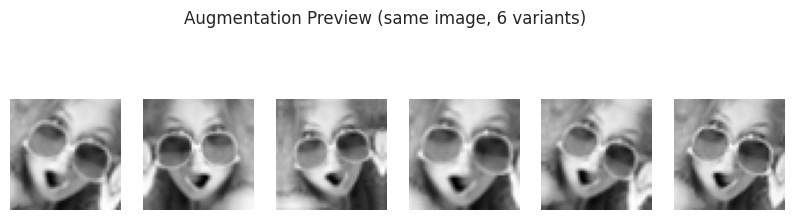

In [18]:
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

# Preview augmentation effect
for images, labels in train_ds.take(1):
    plt.figure(figsize=(10,3))
    for i in range(6):
        augmented = data_augmentation(images[0:1])
        plt.subplot(1,6,i+1)
        plt.imshow(augmented[0].numpy().squeeze(), cmap='gray')
        plt.axis('off')
    plt.suptitle('Augmentation Preview (same image, 6 variants)')
    plt.show()

In [19]:
train_labels_flat = []
for cls_idx, cls in enumerate(class_names):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    train_labels_flat.extend([cls_idx] * len(os.listdir(cls_dir)))

class_weights_arr = compute_class_weight('balanced', classes=np.arange(len(class_names)), y=train_labels_flat)
class_weight_dict = dict(enumerate(class_weights_arr))
print("Class weights:", dict(zip(class_names, class_weights_arr.round(2))))

Class weights: {'angry': np.float64(1.03), 'disgust': np.float64(9.41), 'fear': np.float64(1.0), 'happy': np.float64(0.57), 'neutral': np.float64(0.83), 'sad': np.float64(0.85), 'surprise': np.float64(1.29)}


In [20]:
def build_cnn(input_shape=(48,48,1), num_classes=7):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        data_augmentation,

        layers.Conv2D(32, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

cnn_model = build_cnn()
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,79

 Total params: 1,322,855 (5.05 MB)

 Trainable params: 1,321,703 (5.04 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [22]:
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6),
    ModelCheckpoint('best_fer_model.keras', monitor='val_accuracy', save_best_only=True)
]

In [24]:
EPOCHS = 50

history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Epoch 1/50


E0000 00:00:1785415411.622352      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_1_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


404/404 ━━━━━━━━━━━━━━━━━━━━ 19s 29ms/step - accuracy: 0.2083 - loss: 2.1915 - val_accuracy: 0.1571 - val_loss: 3.9229 - learning_rate: 0.0010
Epoch 2/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.2844 - loss: 1.8444 - val_accuracy: 0.3951 - val_loss: 1.5580 - learning_rate: 0.0010
Epoch 3/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.3526 - loss: 1.6761 - val_accuracy: 0.3976 - val_loss: 1.5600 - learning_rate: 0.0010
Epoch 4/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.3820 - loss: 1.5914 - val_accuracy: 0.3564 - val_loss: 1.8728 - learning_rate: 0.0010
Epoch 5/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.4081 - loss: 1.5336 - val_accuracy: 0.4495 - val_loss: 1.4392 - learning_rate: 0.0010
Epoch 6/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.4295 - loss: 1.4865 - val_accuracy: 0.4794 - val_loss: 1.3747 - learning_rate: 0.0010
Epoch 7/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.4424 - loss: 1.4522

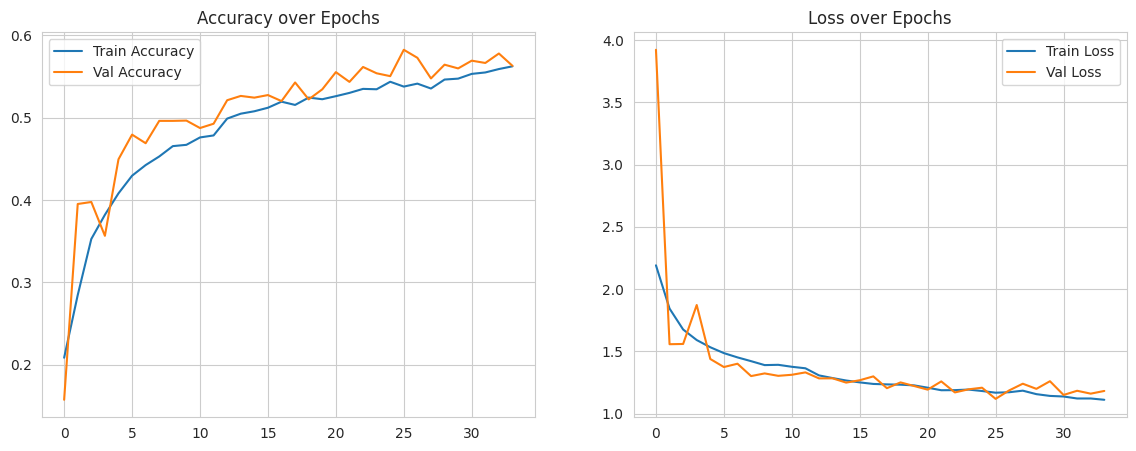

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy over Epochs'); axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss over Epochs'); axes[1].legend()
plt.show()

In [28]:
test_loss, test_accuracy = cnn_model.evaluate(test_ds)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.5815 - loss: 1.1141
Test Accuracy: 0.5815
Test Loss: 1.1141


In [29]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = cnn_model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

       angry       0.58      0.38      0.46       958
     disgust       0.30      0.63      0.40       111
        fear       0.44      0.23      0.30      1024
       happy       0.82      0.81      0.81      1774
     neutral       0.49      0.67      0.57      1233
         sad       0.44      0.49      0.47      1247
    surprise       0.67      0.76      0.71       831

    accuracy                           0.58      7178
   macro avg       0.53      0.57      0.53      7178
weighted avg       0.58      0.58      0.57      7178



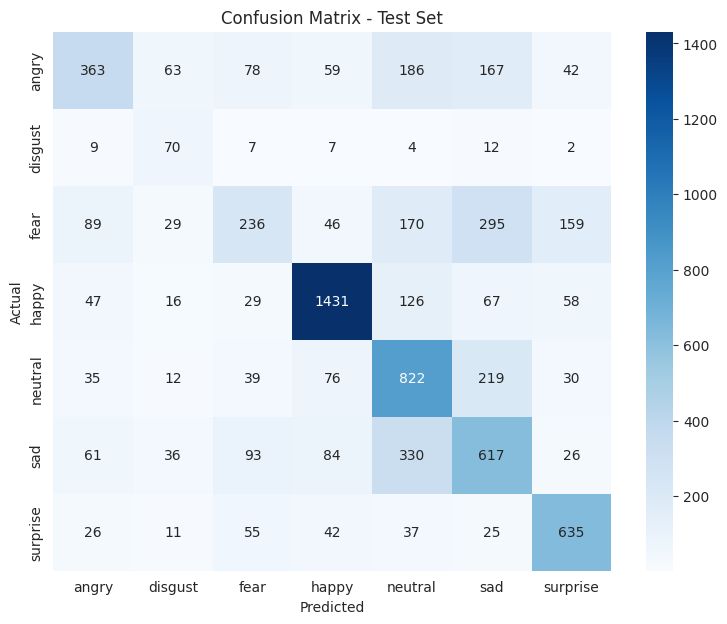

In [30]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()

In [31]:
cnn_model.save('deepfer_cnn_model.keras')
print("Model saved as deepfer_cnn_model.keras")

Model saved as deepfer_cnn_model.keras


True: angry, Predicted: angry, Confidence: 0.71


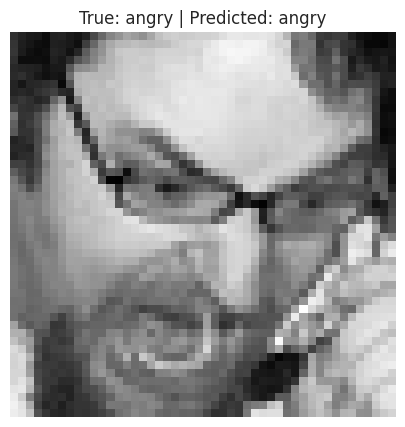

In [32]:
loaded_model = keras.models.load_model('deepfer_cnn_model.keras')

for images, labels in test_ds.take(1):
    sample_img = images[0:1]
    true_label = class_names[np.argmax(labels[0].numpy())]
    pred = loaded_model.predict(sample_img, verbose=0)
    pred_label = class_names[np.argmax(pred[0])]
    print(f"True: {true_label}, Predicted: {pred_label}, Confidence: {pred[0].max():.2f}")

    plt.imshow(sample_img[0].numpy().squeeze(), cmap='gray')
    plt.title(f"True: {true_label} | Predicted: {pred_label}")
    plt.axis('off')
    plt.show()